# Support Vector Machines

## Synthetic two feature binary classification dataset.

`synthetic_binary.csv` is a synthetic (not-real) dataset for a binary classification task. The dataset has two continuous features `feature 1` and `feature 2`, and a binary output label `output`. 

---
## Step 1: Read the dataset and pre-process the features

We read in `synthetic_binary.csv`, build the `X_data` and `y_data` arrays, and split them with scikit-learn's [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html): first an 80-20 stratified split into train and test, then a further 80-20 stratified split of the training portion into train and validation. Stratifying keeps the class balance identical across all three sets, which matters here because the classes are not perfectly even.

Every split uses `random_state=20211008`, so the results below are reproducible.


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import sklearn.metrics
from IPython.display import display
import matplotlib.pyplot as plt
%matplotlib inline

data_df = pd.read_csv('./synthetic_binary.csv')

display(data_df.head())

,feature 1,feature 2,output
0,-1.36,6.69,0.0
1,-8.12,-10.64,1.0
2,8.03,-9.94,1.0
3,-3.39,5.50,0.0
4,9.99,5.57,1.0


In [2]:
feat_df = data_df[['feature 1', 'feature 2']]
output_df = data_df['output']

# create X_data, y_data
X_data = feat_df.values
y_data = output_df.values

# split into train-val-test
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, train_size=0.8, random_state=20211008, stratify=y_data)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, train_size=0.8, random_state=20211008, stratify=y_train)


print('X_data={}'.format(X_data.shape))
print('X_train={}, X_val={}, X_test={}'.format(X_train.shape, X_val.shape, X_test.shape))
print('y_train={}, y_val={}, y_test={}'.format(y_train.shape, y_val.shape, y_test.shape))
print()
print('class % in y_train = {}'.format((np.unique(y_train, return_counts=True)[1]/y_train.shape[0]).round(2)))
print('class % in y_val = {}'.format((np.unique(y_val, return_counts=True)[1]/y_val.shape[0]).round(2)))
print('class % in y_test = {}'.format((np.unique(y_test, return_counts=True)[1]/y_test.shape[0]).round(2)))

X_data=(550, 2)
X_train=(352, 2), X_val=(88, 2), X_test=(110, 2)
y_train=(352,), y_val=(88,), y_test=(110,)

class % in y_train = [0.45 0.55]
class % in y_val = [0.45 0.55]
class % in y_test = [0.45 0.55]


Text(0.5, 1.0, 'X_train Synthetic dataset for a binary classification two-feature task')

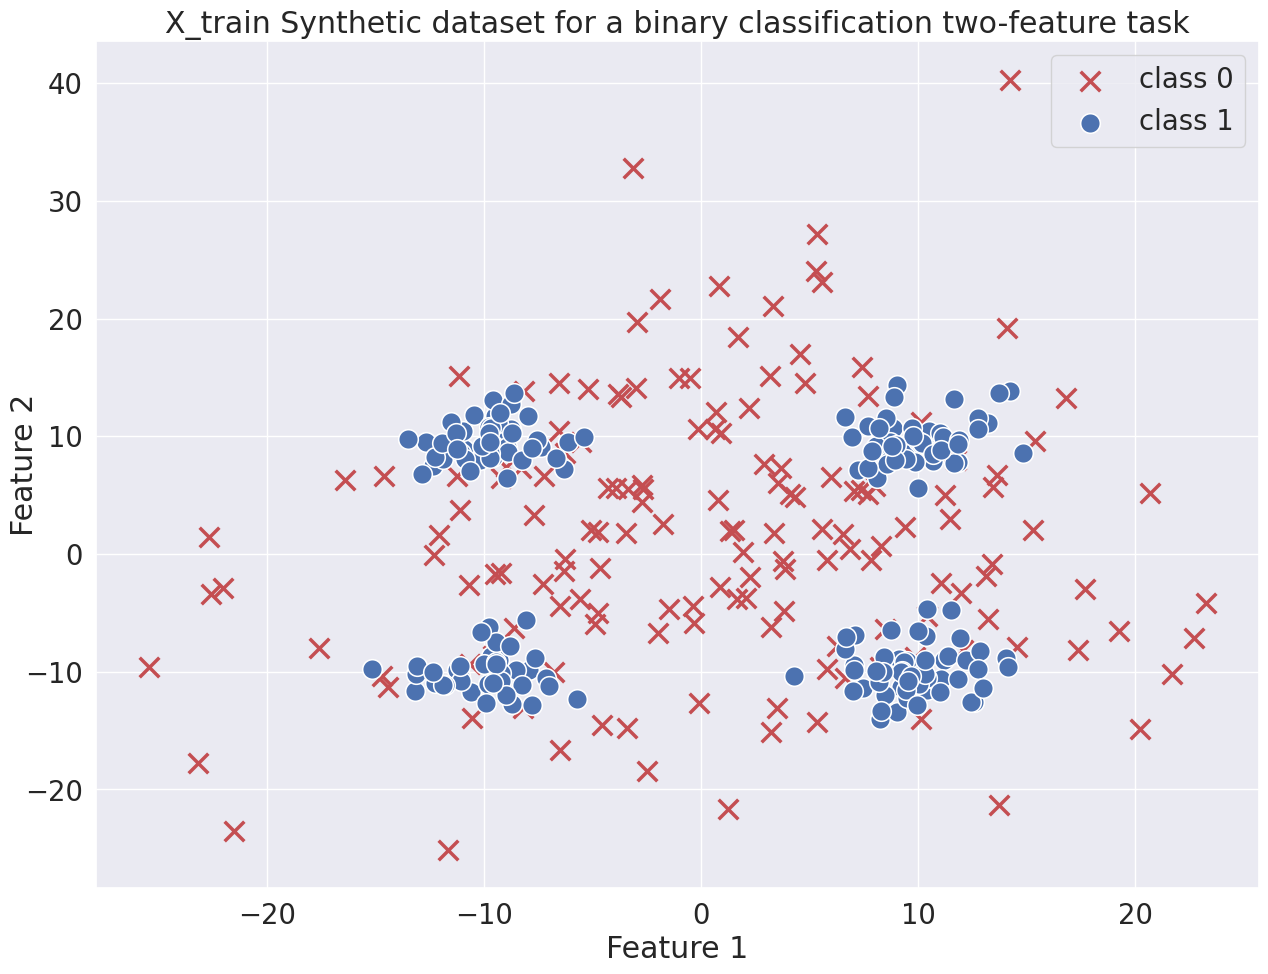

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("paper")
sns.set(font_scale=1.8)

plt.figure(figsize=(15,11))

X_train_1 = X_train[np.where(y_train==1)[0]]
X_train_0 = X_train[np.where(y_train==0)[0]]
sns.scatterplot(x=X_train_0[:,0], y=X_train_0[:,1], linewidth=2.5, marker='x', s=200, color='r', zorder=2, label='class 0')
sns.scatterplot(x=X_train_1[:,0], y=X_train_1[:,1], marker='o', s=200, color='b', zorder=2, label='class 1')

plt.ylabel('Feature 2', labelpad=-10)
plt.xlabel('Feature 1')
plt.title('X_train Synthetic dataset for a binary classification two-feature task')

---
## Step 2: Finding the best SVM using the training and validation sets

We try a linear kernel, polynomial kernels of several degrees, and an RBF kernel, and let validation accuracy decide which one to keep. Documentation for the classifier is at [sklearn.svm.SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html).

Unlike the logistic regression notebook, there is no need to expand the features explicitly here. The kernel trick computes inner products in the higher-dimensional space without ever constructing it, and scikit-learn implements this internally.


In [4]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np

# Initializing for tracking
best_val_acc = 0.0
best_model_config = {}
best_svc_model = None 

# kernel = 'linear'
print("####  kernel = 'linear' ####")
svc_linear = SVC(kernel = 'linear', random_state=20211008)
svc_linear.fit(X_train, y_train)

# Calculate training accuracy -> kind of optional
y_pred_train_linear = svc_linear.predict(X_train)
train_acc_linear = accuracy_score(y_train, y_pred_train_linear)
print(f"Train accuracy (linear): {train_acc_linear:.4f}")

y_pred_val_linear = svc_linear.predict(X_val)
val_acc_linear = accuracy_score(y_val, y_pred_val_linear)
print(f"Validation accuracy (linear):   {val_acc_linear:.4f}")

if val_acc_linear > best_val_acc:
    best_val_acc = val_acc_linear
    best_model_config = {'kernel': 'linear'}
    best_svc_model = svc_linear

print("-------------------------------------")

# kernel = 'poly'
print("#### kernel = 'poly' ####")
poly_degrees = [2, 3, 4, 5, 6] 

for degree in poly_degrees:
    svc_poly = SVC(kernel='poly', degree=degree, random_state=20211008)
    svc_poly.fit(X_train, y_train)
    
    # (Optional) Calculate training accuracy
    y_pred_train_poly = svc_poly.predict(X_train)
    train_acc_poly = accuracy_score(y_train, y_pred_train_poly)
    
    y_pred_val_poly = svc_poly.predict(X_val)
    val_acc_poly = accuracy_score(y_val, y_pred_val_poly)
    print(f"Degree {degree}: Train accuracy = {train_acc_poly:.4f}, Validation accuracy = {val_acc_poly:.4f}")
    
    if val_acc_poly > best_val_acc:
        best_val_acc = val_acc_poly
        best_model_config = {'kernel': 'poly', 'degree': degree}
        best_svc_model = svc_poly

print("-------------------------------------")

# kernel = 'rbf'
print("####  kernel = 'rbf' ####")
svc_rbf = SVC(kernel = 'rbf', random_state=20211008)
svc_rbf.fit(X_train, y_train)

# Calculate training accuracy --> this is optional
y_pred_train_rbf = svc_rbf.predict(X_train)
train_acc_rbf = accuracy_score(y_train, y_pred_train_rbf)
print(f"Train accuracy (rbf): {train_acc_rbf:.4f}")

y_pred_val_rbf = svc_rbf.predict(X_val)
val_acc_rbf = accuracy_score(y_val, y_pred_val_rbf)
print(f"Validation accuracy (rbf):   {val_acc_rbf:.4f}")

if val_acc_rbf > best_val_acc:
    best_val_acc = val_acc_rbf
    best_model_config = {'kernel': 'rbf'}
    best_svc_model = svc_rbf

print("-------------------------------------")

# The final results
print("#### Best Model Configuration ####")
print("The best model found has a validation accuracy of: {:.4f}".format(best_val_acc))
print("The best model parameters are: {}".format(best_model_config))

####  kernel = 'linear' ####
Train accuracy (linear): 0.5455
Validation accuracy (linear):   0.5455
-------------------------------------
#### kernel = 'poly' ####
Degree 2: Train accuracy = 0.5824, Validation accuracy = 0.5682


Degree 3: Train accuracy = 0.5994, Validation accuracy = 0.5682
Degree 4: Train accuracy = 0.7131, Validation accuracy = 0.6932
Degree 5: Train accuracy = 0.5938, Validation accuracy = 0.5568
Degree 6: Train accuracy = 0.7045, Validation accuracy = 0.6591
-------------------------------------
####  kernel = 'rbf' ####
Train accuracy (rbf): 0.8466
Validation accuracy (rbf):   0.8182
-------------------------------------
#### Best Model Configuration ####
The best model found has a validation accuracy of: 0.8182
The best model parameters are: {'kernel': 'rbf'}


In [5]:
# evaluate the best model on X_test, y_test

# Merge Train and Val data
X_train_val = np.vstack([X_train, X_val])
y_train_val = np.hstack([y_train, y_val])

# Create and Train the Final Model
final_svc = SVC(**best_model_config, random_state = 20211008, probability=True)
final_svc.fit(X_train_val, y_train_val)

# Evaluation
y_pred_test = final_svc.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Final Model Configuration: {best_model_config}")
print(f"Final Test Accuracy: {test_acc:.4f}")

Final Model Configuration: {'kernel': 'rbf'}
Final Test Accuracy: 0.8364


## Step 3: Plotting the decision boundary

We plot the decision boundary of the selected model with the test samples overlaid, to see the shape the kernel actually produced.


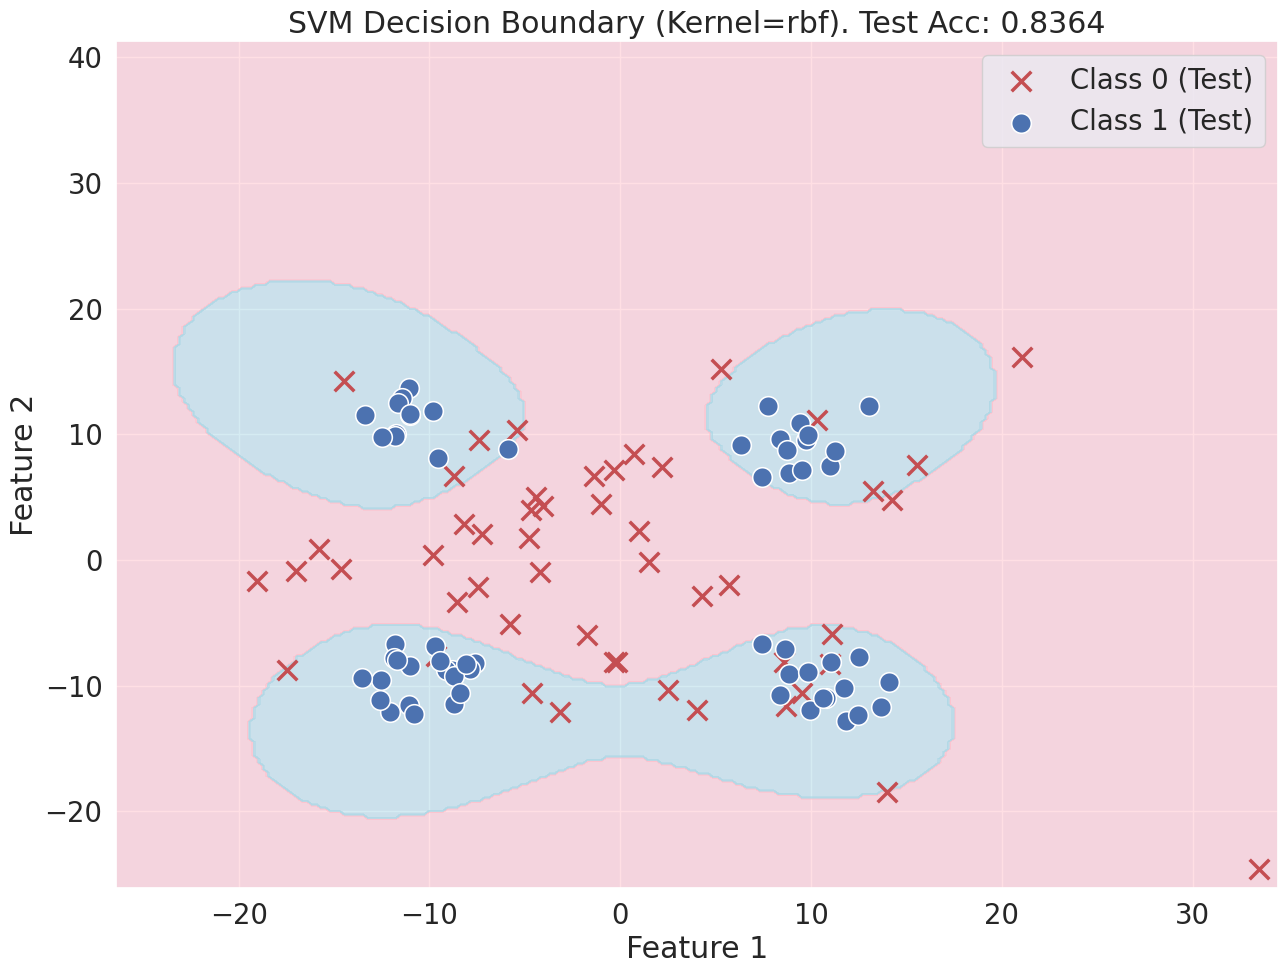

In [6]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import seaborn as sns

# Create a grid of points
x_min, x_max = X_data[:, 0].min() - 1, X_data[:, 0].max() + 1
y_min, y_max = X_data[:, 1].min() - 1, X_data[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))

# Scale the grid points and predict their class
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = final_svc.predict(grid_points)
Z = Z.reshape(xx.shape)

# Plot the results
plt.figure(figsize=(15, 11))

# Plot the decision regions
cmap_light = ListedColormap(['pink', 'lightblue'])
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.5)

# Plot the test data points (unscaled)
X_test1 = X_test[np.where(y_test==1)[0]]
X_test0 = X_test[np.where(y_test==0)[0]]

sns.scatterplot(x=X_test0[:,0], y=X_test0[:,1], linewidth=2.5, marker='x', s=200, color='r', zorder=2, label='Class 0 (Test)')
sns.scatterplot(x=X_test1[:,0], y=X_test1[:,1], marker='o', s=200, color='b', zorder=2, label='Class 1 (Test)')


plt.ylabel('Feature 2')
plt.xlabel('Feature 1')
plt.title(f'SVM Decision Boundary (Kernel={best_model_config.get("kernel")}). Test Acc: {test_acc:.4f}')
plt.legend()
plt.show()